Objetivo y Alcance:
El proyecto se trata de un ejercicio de clasificación, donde el objetivo es encontrar los clientes que tengan mayores probabilidades de dejar de contratar servicios con la compañia. El impacto que buscamos es generar estrategias de retención para tratar de que esos clientes no se pierdan. El primer enfoque puede ser hacer un solo df de todos los archivos. En este proceso, para las caracteristicas que son solo Sí/No, se puede hacer un reemplazo por 1/0; Y en los archivos que tienen menos observaciones, se tendría que trabajar los Nan que se generen al fusionar los dfs, con un 0 para indicar que no contaban con esos servicios. También se tendrá que hacer un OHE para las caracteristicas con más de dos valores.

Plan Detallado:

1.- EDA: Se analisaran los archivos para identificar valores nulos, desequilibrio de clases y otros preprocesamientos que se deban aplicar a los datos.
El valor objetivo es 'End Date', donde el valor No, significa que el cliente aun esta contratando servicios. Mientras que una fecha determinada significa que el cliente ha dejado de contratar servicios; Este tipo es a los que haremos referencia más adelante para estrategías de retención. En esta variable se indagará si hay desequilibrio de clases, para ver si es necesario equilibrar. Se hará también codificación de 1/0 para End Date y se mostrara la distribución de los valores por medio de tablas como histogramas.

2.- Entrenar y mejorar la calidad de los modelos. En esta parte se hará el equilibrio de clases si es necesario, además de una codificación 1/0 para las caracteristicas de afirmación o negación, ya que necesitamos que todo este en escala númerica para que el modelo pueda trabajar los datos. Por esta misma razón se aplicará ohe a las caracteristicas con multiples clases(Typu, PaymentMethod). También para mejorar la calidad del modelo se usara el escalado de datos para las caracteristicas numericas(MonthlyCharges, TotalCharges), con esto buscamos que no se priorice alguna caracteristica solo por sus valores intrinsecos frente a otras que podrían tener la misma relevancia.
Se creara un modelo de regresión lineal como base de comparación, también un bosque aleatorio y se utilizaran gradient boosting, adicionalmente se podría probar una red convolusional. Se usará validación cruzada para el bosque y para las maquinas de gradiente. Las metricas que se usarán para medir la eficacia del modelo serán AUC-ROC y exactitud.

3.- Selección del mejor modelo para aplicar el conjunto de prueba a este y sacar los clientes a los que se debe enfocar las estrategias de retención.

Comunicación y entrega:
Los resultados se presentarán mediante la grafica AUC-Roc y la metrica de accuracy. Mediante estas metricas podremos observar la calidad del modelo y sabremos a que tipo de clientes deberíamos aplicar estrategias de retención.

In [125]:
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve


df_contract = pd.read_csv('/Users/IvanSoto/Desktop/Python/Final/final_provider/contract.csv')
df_personal = pd.read_csv('/Users/IvanSoto/Desktop/Python/Final/final_provider/personal.csv')
df_internet = pd.read_csv('/Users/IvanSoto/Desktop/Python/Final/final_provider/internet.csv')
df_phone = pd.read_csv('/Users/IvanSoto/Desktop/Python/Final/final_provider/phone.csv')

In [126]:
df_contract.info()
df_contract.sample(5)
df_contract['EndDate'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


array(['No', '2019-12-01 00:00:00', '2019-11-01 00:00:00',
       '2019-10-01 00:00:00', '2020-01-01 00:00:00'], dtype=object)

In [127]:
df_personal.info()
df_personal.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


,customerID,gender,SeniorCitizen,Partner,Dependents
2379,3757-NJYBX,Male,1,Yes,No
4343,7130-VTEWQ,Female,1,No,No
4650,6509-TSGWN,Female,0,Yes,Yes
5424,6435-VWCCY,Male,1,Yes,No
299,6390-DSAZX,Female,0,No,Yes


In [128]:
df_internet.info()
df_internet.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
1663,8383-SGHJU,DSL,Yes,No,No,Yes,No,No
2411,2141-RRYGO,DSL,No,Yes,No,No,Yes,Yes
640,5671-RQRLP,Fiber optic,No,No,No,No,No,No
84,7123-WQUHX,Fiber optic,No,No,Yes,Yes,Yes,No
5045,8761-NSOBC,Fiber optic,No,Yes,No,Yes,Yes,Yes


In [129]:
df_phone.info()
df_phone.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


,customerID,MultipleLines
3352,5312-UXESG,Yes
210,9903-LYSAB,Yes
1127,0319-QZTCO,No
1931,7707-PYBBH,No
5730,6603-QWSPR,No


In [130]:
#Hacemos la codificación para el target y vemos si hay desequilibrio de clases
def binario(valor):
    if valor == 'No':
        return 0
    else:
        return 1
    
df_contract['EndDate'] = df_contract['EndDate'].apply(binario)

print(df_contract['EndDate'].value_counts(normalize=True)) #Para ver el porcentaje de cada clase
df_contract['EndDate'].sample(10)

EndDate
0    0.73463
1    0.26537
Name: proportion, dtype: float64


1994    0
4       1
649     0
3548    0
1259    1
2740    1
2757    0
2444    1
4538    1
2478    0
Name: EndDate, dtype: int64

/var/folders/lj/72n9dkzd4qx4svqgj407lzw00000gn/T/ipykernel_8863/2163768071.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Actuales', 'Exclientes'])


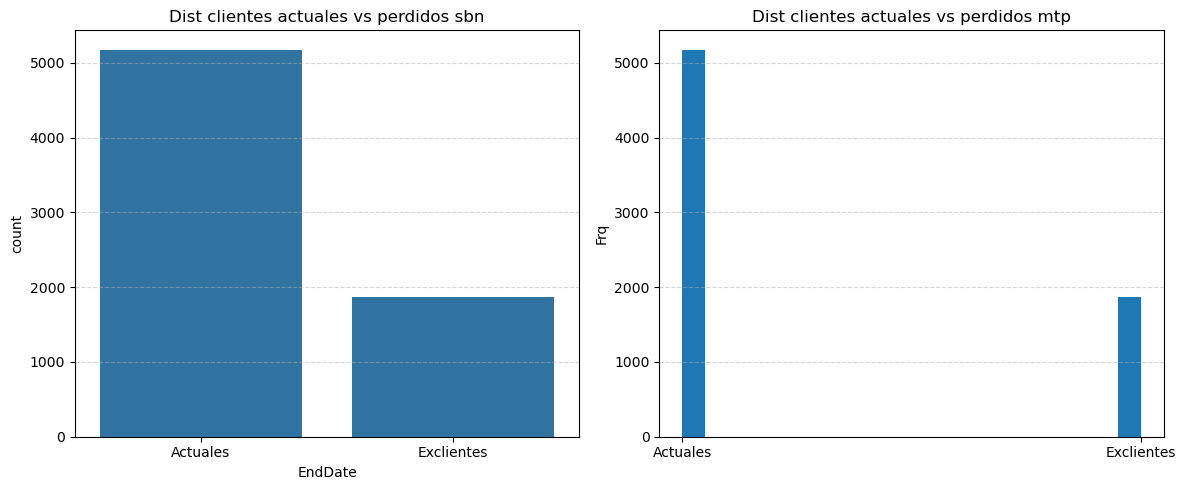

In [131]:
#Visualizamos la distribución
fig, axs = plt.subplots(1,2, figsize=(12, 5))

ax = axs[0]

sbn.countplot(x='EndDate', data=df_contract, ax=ax)
ax.set_xticklabels(['Actuales', 'Exclientes'])
ax.grid(True, axis='y', linestyle='--', alpha = .5)
ax.set_title('Dist clientes actuales vs perdidos sbn')

ax = axs[1]
df_contract['EndDate'].plot.hist(bins= 20, title = 'Dist clientes actuales vs perdidos mtp', ylabel='Frq', ax=ax)
plt.grid(True, axis='y', linestyle='--', alpha = .5)
plt.xticks(ticks=[0,1], labels=['Actuales', 'Exclientes'])

fig.tight_layout()

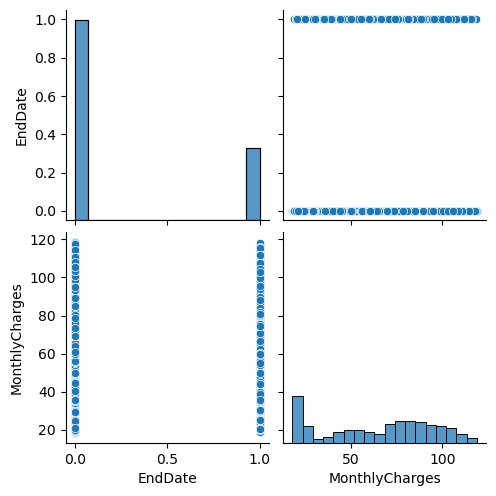

In [132]:
g = sbn.pairplot(df_contract)
g # Buscamos correlaciones visuales, aunque en este caso las columnas numericas son pocas, por lo que no se ve mucho.

Es necesario equilibrar las clases, habrá que hacer un sobreescalamiento de la clase de Exclientes(1)

# Preprocesamiento de Datos

In [133]:
#Hacemos merge para unir df's en uno solo
#df_contract, df_internet, df_phone, df_personal
df = df_contract.merge(df_personal, on='customerID', how='outer')\
    .merge(df_internet, on='customerID', how='left')\
    .merge(df_phone, on='customerID', how='left')

df.reset_index(drop=True, inplace=True)
df.sample(5)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
4899,6899-PPEEA,2016-09-01,1,Month-to-month,Yes,Electronic check,96.55,3580.3,Female,1,No,No,Fiber optic,No,No,No,No,Yes,Yes,Yes
2736,3892-NXAZG,2014-02-01,0,Two year,Yes,Credit card (automatic),114.05,8289.2,Male,0,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes
2728,3884-HCSWG,2018-06-01,1,Month-to-month,Yes,Electronic check,70.00,1144.5,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
6400,9065-ZCPQX,2014-02-01,0,Two year,No,Bank transfer (automatic),78.85,5763.15,Male,0,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Yes
6407,9070-BCKQP,2014-02-01,0,Two year,Yes,Credit card (automatic),110.15,7881.2,Female,0,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Yes


In [134]:
df.fillna('No', inplace=True) #Rellenamos nan con No para definir que no cuentan con el servicio
print(df.isna().sum()) #Verificamos que no haya nan

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64


In [135]:
df.nunique() #Valores unicos
#df['SeniorCitizen'] ya no se debe codificar.

customerID          7043
BeginDate             77
EndDate                2
Type                   3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
InternetService        3
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
TechSupport            2
StreamingTV            2
StreamingMovies        2
MultipleLines          2
dtype: int64

In [136]:
print(list(df.columns))

['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


In [137]:
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('',0).astype(float) #Tenía observaciones vacias por lo que necesitaba procesamiento
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   int64         
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

In [138]:
df.sample(5)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
5917,8329-IBCTI,2019-12-01,1,Month-to-month,No,Mailed check,19.65,19.65,Female,0,No,No,No,No,No,No,No,No,No,No
5184,7294-TMAOP,2019-10-01,1,Month-to-month,No,Electronic check,90.55,90.55,Female,0,No,No,Fiber optic,No,No,No,No,Yes,Yes,No
5864,8242-PDSGJ,2014-04-01,0,Two year,Yes,Credit card (automatic),39.15,2692.75,Male,0,Yes,No,DSL,Yes,No,Yes,Yes,No,No,No
453,0666-UXTJO,2017-04-01,0,Month-to-month,Yes,Credit card (automatic),85.20,2874.45,Male,1,Yes,No,Fiber optic,No,No,Yes,No,Yes,No,No
2628,3737-XBQDD,2018-02-01,0,Month-to-month,Yes,Bank transfer (automatic),84.85,2048.80,Male,0,No,No,Fiber optic,No,Yes,Yes,No,No,No,Yes


In [139]:
#g = sbn.pairplot(df, kind='scatter', hue='EndDate', diag_kind='hist', markers=["o", "s"], palette='Set1') # Diagonal con histogramas
#g # Buscamos correlaciones visuales

# Entrenar Modelos

In [140]:
from sklearn.model_selection import train_test_split as tts, cross_val_score as cvs
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.utils import shuffle

#Definimos Target
X = df.drop(columns=['EndDate', 'BeginDate', 'customerID'], axis= 1)
y = df['EndDate']
ids = df['customerID']

#Sobremuestreo
zero = len(df[df['EndDate']==0])
one = len(df[df['EndDate']==1]) #Clase a sobreescalar
prop = int(round(zero/one)) # Calculamos la proporcion por la cual habrá que repetir los valores positivos para equilibrar)

X_zeros = X[y==0]
X_ones = X[y==1]
y_zeros = y[y==0]
y_ones = y[y==1]

X = pd.concat([X_zeros] + [X_ones] * prop)
y = pd.concat([y_zeros] + [y_ones] * prop)

X, y = shuffle(X, y, random_state= 123)
print(y.value_counts())
print(y.value_counts(normalize=True)) #Verificamos que esté balanceado verificando la proporción(frecuencia relativa)

#Dividimos datasets
features_train, features_temp, target_train, target_temp = tts(X, y, test_size=.4 , random_state= 123)
features_val, features_test, target_val, target_test = tts(features_temp, target_temp, test_size=.5, random_state=123)

#Codificación ordinal para columnas binarias y OHE para categoricas.
#dtype=int para 1 y 0 #OHE para variables categoricas

#df = pd.get_dummies(df, columns=['Type','PaymentMethod','InternetService'], drop_first=True) usamos ohe de scikit para poder transformar todos los datasets

#Definimos los datasets para CatBoost ya que no es necesario escalar ni codificar
features_train_cb = features_train.copy()
features_val_cb = features_val.copy()
features_test_cb = features_test.copy()

cat_cols_cb=['PaperlessBilling', 'gender', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
              'StreamingMovies', 'StreamingTV', 'MultipleLines', 'Type', 'PaymentMethod', 'InternetService']

#Codificación OHE y Ordinal
cat_cols=['PaperlessBilling', 'gender', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
              'StreamingMovies', 'StreamingTV', 'MultipleLines']

encoder = OrdinalEncoder()

features_train[cat_cols] = pd.DataFrame(encoder.fit_transform(features_train[cat_cols]))
features_val[cat_cols] = pd.DataFrame(encoder.transform(features_val[cat_cols]))
features_test[cat_cols] = pd.DataFrame(encoder.transform(features_test[cat_cols]))

ohe_cols = ['Type','PaymentMethod','InternetService']

ohe = OneHotEncoder(drop='first', handle_unknown= 'infrequent_if_exist', min_frequency= .05, sparse_output= False)

ohe_train = ohe.fit_transform(features_train[ohe_cols]) #Creamos los numpy arrays para luego convertirlos en dataframes
ohe_val = ohe.transform(features_val[ohe_cols])
ohe_test = ohe.transform(features_test[ohe_cols])

ohe_train_df = pd.DataFrame(ohe_train, columns= ohe.get_feature_names_out(ohe_cols), index= features_train.index) #Creamos los df de ohe con nombres de columnas
ohe_val_df = pd.DataFrame(ohe_val, columns= ohe.get_feature_names_out(ohe_cols), index= features_val.index)
ohe_test_df = pd.DataFrame(ohe_test, columns= ohe.get_feature_names_out(ohe_cols), index= features_test.index)

features_train = pd.concat([features_train.drop(columns= ohe_cols), ohe_train_df], axis=1) 
features_val = pd.concat([features_val.drop(columns= ohe_cols), ohe_val_df], axis= 1)
features_test = pd.concat([features_test.drop(columns= ohe_cols), ohe_test_df], axis= 1)

#Escalador de datos numericos
numeric = ['MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
scaler.fit_transform(features_train[numeric])
features_val[numeric] = scaler.transform(features_val[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

#Función para evaluar
def eval_model(model, features, target):
    predict = model.predict(features)
    probs = model.predict_proba(features)[:,1]
    cm = confusion_matrix(target, predict)

    print('Accuracy:', accuracy_score(target, predict))
    print('ROC AUC:', roc_auc_score(target, probs))
    print('Confusion Matrix:\n', cm)

    fpr, tpr, thresholds = roc_curve(target, probs)
    plt.figure()
    plt.plot(fpr, tpr) #Gráfica ROC

    plt.plot([0,1],[0,1], linestyle='--') #Curva ROC para modelo aleatorio

    plt.xlim([0,1])
    plt.ylim([0,1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.show()

EndDate
1    5607
0    5174
Name: count, dtype: int64
EndDate
1    0.520082
0    0.479918
Name: proportion, dtype: float64


In [141]:
#Rellenamos los nans con 0 para definir que no cuentan con el servicio y evitar errores en los modelos.
features_train.fillna(0, inplace=True)
features_val.fillna(0, inplace=True)
features_test.fillna(0, inplace=True)

print(features_train.isna().sum(),'\n', features_train.isna().sum(), '\n', features_test.isna().sum())
print(features_train.shape, features_val.sample(2))

PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
MultipleLines                            0
Type_One year                            0
Type_Two year                            0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
InternetService_Fiber optic              0
InternetService_No                       0
dtype: int64 
 PaperlessBilling                         0
MonthlyCharges                         

Accuracy: 0.7059369202226345
ROC AUC: 0.7917300091213136
Confusion Matrix:
 [[773 239]
 [395 749]]


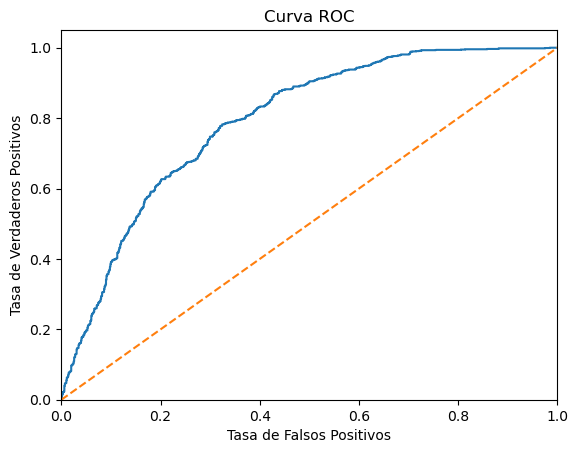

In [142]:
#Modelo lineal para referencia
model_rl = LR(solver='liblinear', random_state=123)
model_rl.fit(features_train, target_train)
eval_model(model_rl, features_val, target_val)

In [ ]:
#Modelo de Bosque Aleatorio
best_score = 0
best_est = 0
best_depth = 0

#Probamos con varios hiperparametros para encontrar los mejores
for est in range(126, 150):
    for depth in range(5, 9):
        model_rf = RFC(n_estimators= est, max_depth= depth, class_weight='balanced', random_state=123)
        model_rf.fit(features_train, target_train)
        probs = model_rf.predict_proba(features_val)[:,1]
        score = roc_auc_score(target_val, probs)
    
        if score > best_score:
            best_score = score
            best_est = est
            best_depth = depth

#Reflejamos los mejores hiperparametros.
print('El mejor ROC AUC, estimador y profundidad fueron= {},{},{}'.format(best_score, best_est, best_depth))

El mejor ROC AUC, estimador y profundidad fueron= 0.8035160244893447,145,6


In [159]:
cross_val_f = cvs(model_rf, features_train, target_train, cv=5, scoring='roc_auc')

print('ROC AUC de CV:', cross_val_f.mean())
print('Desviación Estandar de CV:', cross_val_f.std())

ROC AUC de CV: 0.8670172435452077
Desviación Estandar de CV: 0.009851248234223972


Accuracy: 0.7388682745825603
ROC AUC: 0.8035160244893447
Confusion Matrix:
 [[639 373]
 [190 954]]


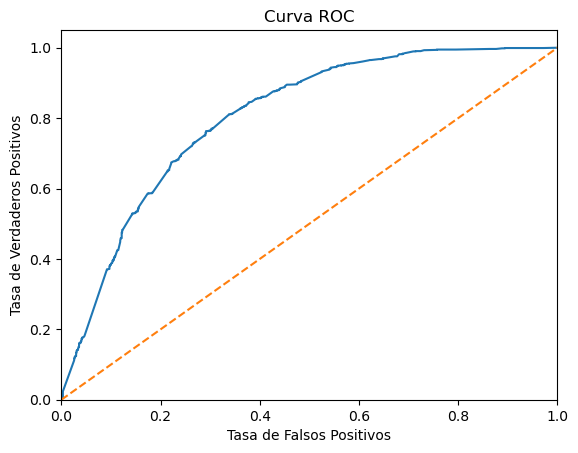

In [160]:
#Probamos el bosque con los mejores hiperparametros
model_ff = RFC(n_estimators= best_est, max_depth= best_depth, class_weight='balanced', random_state=123).fit(features_train, target_train)

eval_model(model_ff, features_val, target_val)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Training until validation scores don't improve for 5 rounds
Early stopping, best iteration is:
[32]	valid_0's l2: 0.182438	valid_0's binary_logloss: 0.545321
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
ROC AUC de CV: 0.855768633654385
Desviación Estandar de CV: 0.011314888287335005

Accuracy: 0.7268089053803339
ROC AUC: 0.7932649119655049
Confusion Matrix:
 [[ 563  449]
 [ 140 1004]]


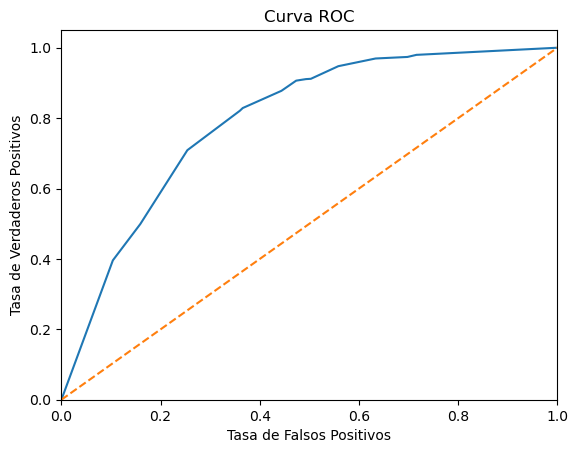

In [145]:
#Modelo de gradiente
import lightgbm as lgb

gbm = lgb.LGBMClassifier(num_leaves= 10, learning_rate= .05, n_estimators=100, objective= 'binary', n_jobs= 2, is_unbalance= True, random_state= 123, force_row_wise= True, verbose= 0)

gbm.fit(features_train, target_train, eval_set=[(features_val, target_val)],eval_metric='l2', callbacks=[lgb.early_stopping(5)])

#gbpred = gbm.predict(features_test, num_iteration= gbm.best_iteration_)
cross_val_g = cvs(gbm, features_train, target_train, cv=5, scoring='roc_auc')

print('ROC AUC de CV:', cross_val_g.mean())
print('Desviación Estandar de CV:', cross_val_g.std())
print()

eval_model(gbm, features_val, target_val)

0:	test: 0.8102093	best: 0.8102093 (0)	total: 270ms	remaining: 22m 32s
500:	test: 0.8604413	best: 0.8604517 (498)	total: 1m 6s	remaining: 10m
1000:	test: 0.8723003	best: 0.8723003 (1000)	total: 2m 26s	remaining: 9m 43s
1500:	test: 0.8788230	best: 0.8788351 (1499)	total: 3m 46s	remaining: 8m 48s
2000:	test: 0.8866491	best: 0.8866491 (2000)	total: 5m 17s	remaining: 7m 55s
2500:	test: 0.8951658	best: 0.8951658 (2500)	total: 9m 59s	remaining: 9m 58s
3000:	test: 0.9001212	best: 0.9001298 (2999)	total: 12m 43s	remaining: 8m 28s
3500:	test: 0.9037766	best: 0.9037913 (3496)	total: 16m 10s	remaining: 6m 55s
4000:	test: 0.9065139	best: 0.9065139 (4000)	total: 17m 23s	remaining: 4m 20s
4500:	test: 0.9087743	best: 0.9087743 (4500)	total: 18m 33s	remaining: 2m 3s
4999:	test: 0.9103075	best: 0.9103118 (4995)	total: 19m 39s	remaining: 0us

bestTest = 0.9103118349
bestIteration = 4995

Shrink model to first 4996 iterations.
Accuracy: 0.851113172541744
ROC AUC: 0.9103118349042262
Confusion Matrix:
 [[ 

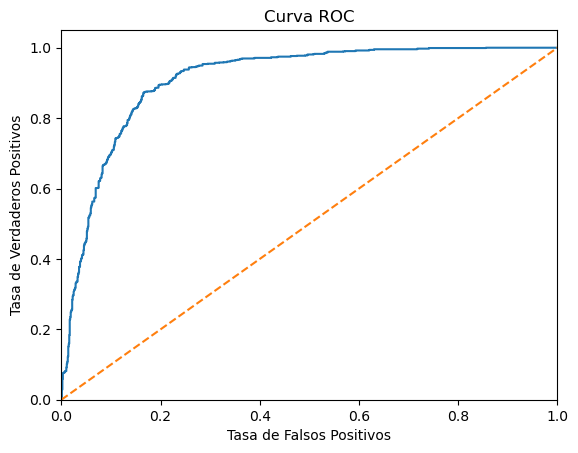

In [ ]:
#Modelo con CatBoost
from catboost import CatBoostClassifier as CBC, Pool

test_data = catboost_pool = Pool(features_test_cb, target_test, cat_features= cat_cols_cb) #Para puebas finales

train_data = catboost_pool = Pool(features_train_cb, target_train, cat_features= cat_cols_cb)

val_data = catboost_pool = Pool(features_val_cb, target_val, cat_features= cat_cols_cb)

model_cb = CBC(iterations=5000,learning_rate= .01, l2_leaf_reg=5, depth=10, auto_class_weights='Balanced',loss_function='Logloss', eval_metric='AUC', random_seed=123, verbose=500)

model_cb.fit(train_data, eval_set= val_data, early_stopping_rounds= 750, use_best_model=True)

eval_model(model_cb, features_val_cb, target_val)


In [ ]:
#Modelo con Red Neuronal
from tensorflow import keras

model_nn = keras.models.Sequential()

model_nn.add(keras.layers.Dense(256, activation='sigmoid', input_dim=features_train.shape[1]))
model_nn.add(keras.layers.Dropout(.3))
model_nn.add(keras.layers.Dense(176, activation='sigmoid'))
model_nn.add(keras.layers.Dropout(.2))
#model_nn.add(keras.layers.Dense(64, activation='sigmoid'))
#model_nn.add(keras.layers.Dropout(.2))
#model_nn.add(keras.layers.Dense(32, activation='sigmoid'))
#model_nn.add(keras.layers.Dropout(.2))
model_nn.add(keras.layers.Dense(56, activation='sigmoid'))
model_nn.add(keras.layers.Dropout(.05))
model_nn.add(keras.layers.Dense(4, activation='sigmoid'))
model_nn.add(keras.layers.Dense(1, activation='sigmoid'))

optimizer = keras.optimizers.Adam(learning_rate=.0001)

model_nn.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['auc', 'acc'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=11, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=.2, patience=11, min_lr=.000001)

model_nn.fit(features_train, target_train, epochs=100, verbose=0, validation_data=(features_val, target_val), callbacks=[early_stopping, reduce_lr])

model_nn.evaluate(features_val, target_val)

2025-08-27 10:41:48.951933: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.6705 - auc: 0.7360 - loss: 0.6504


[0.647497832775116, 0.7471293210983276, 0.6832096576690674]

# Prueba con el mejor modelo

ROC AUC en test del mejor modelo (CatBoost): 0.9150929433287496
Accuracy para test de CatBoost: 0.8484005563282336
Confusion matrix para CB:
 [[ 811  235]
 [  92 1019]]


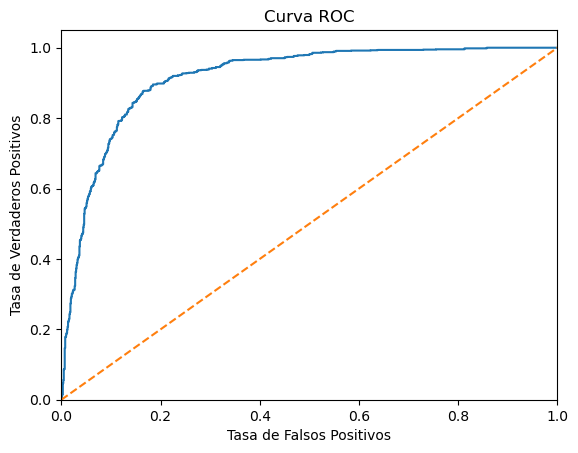

In [154]:
#El modelo con el mejor resultado en el set de validación fue el de CatBoost, por lo que tomaremos ese para la prueba final.
#Este modelo en la validación tuvo un desempeño muy cercano al bosque sin utilizar Pool, por lo que en la prueba utilizamos el 'test_data' ya que mejora el rendimiento.

probs_cb = model_cb.predict_proba(test_data)[:,1]

score_cb = roc_auc_score(target_test, probs_cb)

pred_cb = model_cb.predict(test_data)
acc_cb = accuracy_score(target_test, pred_cb)

print('ROC AUC en test del mejor modelo (CatBoost):', score_cb)
print('Accuracy para test de CatBoost:', acc_cb)
print('Confusion matrix para CB:\n', confusion_matrix(target_test, pred_cb))

fpr, tpr, thresholds = roc_curve(target_test, probs_cb)
plt.figure()
plt.plot(fpr, tpr) #Gráfica ROC

plt.plot([0,1],[0,1], linestyle='--') #Curva ROC para modelo aleatorio

plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.show()

Accuracy: 0.7399165507649513
ROC AUC: 0.8080136407522206
Confusion Matrix:
 [[663 383]
 [178 933]]


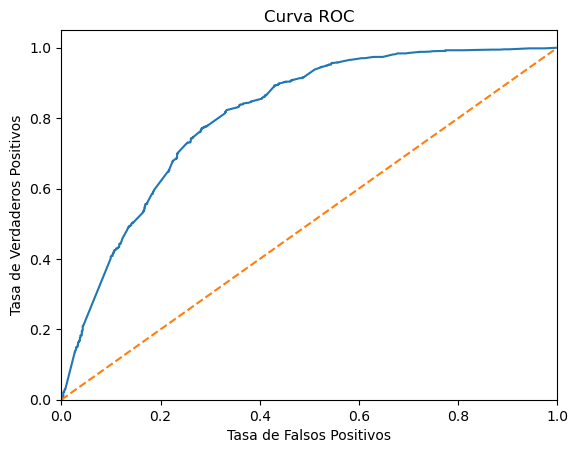

In [161]:
#También probamos el bosque con los mejores hiperparametros, ya que tuvo un buen desempeño.

eval_model(model_ff, features_test, target_test)


# Conclusión
De acuerdo a nuestra metrica objetivo, el modelo con mejores resultados es Catboost, seguido del bosque aleatorio, y si tomamos en cuenta nuestra metrica secundaria (Accuracy), Catboost es superior a todos los demás. Se realizo Validación Cruzada en Light GBM y en bosque aleatorio, ambos tuvieron metricas bastante altas, pero al correrlos con el set de validación, sus metricas clave bajaron considerablemente. Se hizo tambien una red neuronal sencilla para probarla con una regresión, sin embargo, el desempeño fue inferior a los demás modelos. 
A continuación se muestran todos los modelos rankeados de mayor a menor de acuerdo a su desempeño en AUC ROC y Accuracy:

- Catboost: Es el modelo con mejor desempeño de todos, la diferencia con los demás es amplia. Su contra es que el tiempo de procesamiento es bastante más alto que los demás.

Accuracy: 0.8484005563282336

ROC AUC: 0.9150929433287496

- Bosque Aleatorio: Es es segundo mejor modelo, aunque necesita tiempo de procesamiento para encontrar los mejores hiperparametros pero su desempeño es bueno.

Accuracy: 0.7399165507649513

ROC AUC: 0.8080136407522206

- Light GBM: Aunque es un modelo de gradiente con una velocidad de procesamiento muy rápida, su desempeño es deficiente.

Accuracy: 0.7268089053803339

ROC AUC: 0.7932649119655049

- Regresión Logistica: Modelo inicial y más sencillo para tener como referencia.

Accuracy: 0.7059369202226345

ROC AUC: 0.7917300091213136

- Red Neuronal: En general, tuvo el peor desempeño de todos.
acc: 0.6705 - auc: 0.7360

Edit: EL accuracy para un modelo desequilibrado no es una metrica tan buena, ya que solo prediciendo la clase mayoritaria ya tendríamos un score medio alto. Por lo que se debería considerar también otra metrica como F1 o recall. El AUC ROC es una buena metrica para datos con clases desbalanceadas.

*Comentarios finales*

¿Qué pasos del plan se realizaron y qué pasos se omitieron (explica por qué)?
Primero leí el caso, y con la información que había asigne el target a end date. El proposito del proyecto fue encontrar a los clientes que tienen más probabilidades de dejar de contratar servicios con la compañia. Por lo que se buscaba crear un modelo con el mayor puntaje ROC posible, ya que esta metrica no se ve afectada por la distribución de las clases

¿Qué dificultades encontraste y cómo lograste resolverlas?
Lo primero que noté en los datos es que estaban desbalanceados, con una proporción mucho mayor de la clase negativa(0), que eran los clientes que aun contaban con servicios contratados, por lo que se debía hacer una sobreescalado para la clase minoritaria.
También mediante el analisis exploratorio, se observó que era necesaria tanto una codificación OHE para 3 caracteristicas, como una codificaión ordinal para la mayoría de las demás caracteristicas. Los datos de la mayoría eran strings, por lo que también se reemplazaron los valores Sí/No, por 1/0, para que los modelos pudieran leerlos. Y se encontraron algunas columnas.

¿Cuáles fueron algunos de los pasos clave para resolver la tarea?
Algunos pasos clave para la tarea, fueron el codificar el target para que pudiera ser leído por los modelos. Y también hacer un merge de todos los dataframes y preprocesar los datos ya que estaban todos juntos. Reemplazar valores nulos por No para defirnir que no se contaba con esos servicios.
Ya que estaba todo junto y listo para procesar, realicé la codificación de caracteristicas mediante OHE y Ordinal Encoder para poder meter los datasets a los modelos sin problema.

Un paso clave para el modelo de bosque aleatorio fue hacer varias iteraciones sobre el modelo para buscar los mejores hiperparametros.

En la red neuronal, también se probaron algunas arquitecturas con diferentes números de neuronas y funciones de activación, aunque este modelo no resulto tan efectivo para este problema.

Consideré también un modelo de catboost, para este modelo no era necesario codificación de caracteristicas por lo que se definieron variables exclusivas para este modelo.

¿Cuál es tu modelo final y qué nivel de calidad tiene?
El modelo final es CatBoost, ya que aun cuando es el modelo más tardado en procesar los datos. Esta vez el tiempo no es una limitante, y los resultados son superiores a los demás modelos, la calidad es excelente. A continuación se presentan los resultados:

Metrica principal.
ROC AUC: 0.9150929433287496

Metrica secundaria.
Accuracy: 0.8484005563282336
